In [1]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
pretraining_csv = '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/pretrain_stats.csv'

In [3]:
df = pd.read_csv(pretraining_csv)

In [4]:
df.head()

,file,sensor,time,lat,lon,sat_zenith,sat_azimuth,solar_zenith,solar_azimuth,bad_pixels,...,B14_mean,B14_std,B15_min,B15_max,B15_mean,B15_std,B16_min,B16_max,B16_mean,B16_std
0,20180102210039_patch_907_983.nc,GOES,2018-01-02 21:05:57.567625024,23.754288,-103.14522,42.376415,313.37158,56.832867,143.697310,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20180102221539_patch_1638_2684.nc,GOES,2018-01-02 22:20:57.879809984,-8.925537,-85.49774,17.378174,229.53441,67.185490,111.128685,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20180102221539_patch_3248_3501.nc,GOES,2018-01-02 22:20:57.879809984,-25.384842,-52.34424,39.436913,141.28351,90.167780,115.830390,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20180103011539_patch_2758_3172.nc,GOES,2018-01-03 01:20:57.631253952,-18.310730,-64.03351,25.716702,150.43558,119.668724,131.444930,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20180103011539_patch_2834_1994.nc,GOES,2018-01-03 01:20:57.631253952,3.781342,-63.27835,15.921446,72.87954,133.103590,118.113396,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [212]:
MSG_channels = ['VIS006', 'VIS008', 'IR_016', 'IR_039', 'IR_087', 'IR_097', 'IR_108', 'IR_120', 'IR_134', 'WV_062', 'WV_073']
GOES_channels = ['CMI_C01', 'CMI_C02', 'CMI_C03', 'CMI_C04', 'CMI_C05', 'CMI_C06', 'CMI_C07', 'CMI_C08', 'CMI_C09', 'CMI_C10', 'CMI_C11', 'CMI_C12', 'CMI_C13', 'CMI_C14', 'CMI_C15', 'CMI_C16']
HIM_channels = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B13', 'B14', 'B15', 'B16']

channels = {
    'MSG': MSG_channels,
    'GOES': GOES_channels,
    'Himawari': HIM_channels
}

In [54]:
satellite = 'MSG'
metric = 'mean'

columns = [f'{ch}_{metric}' for ch in channels[satellite]]
data = df[columns]

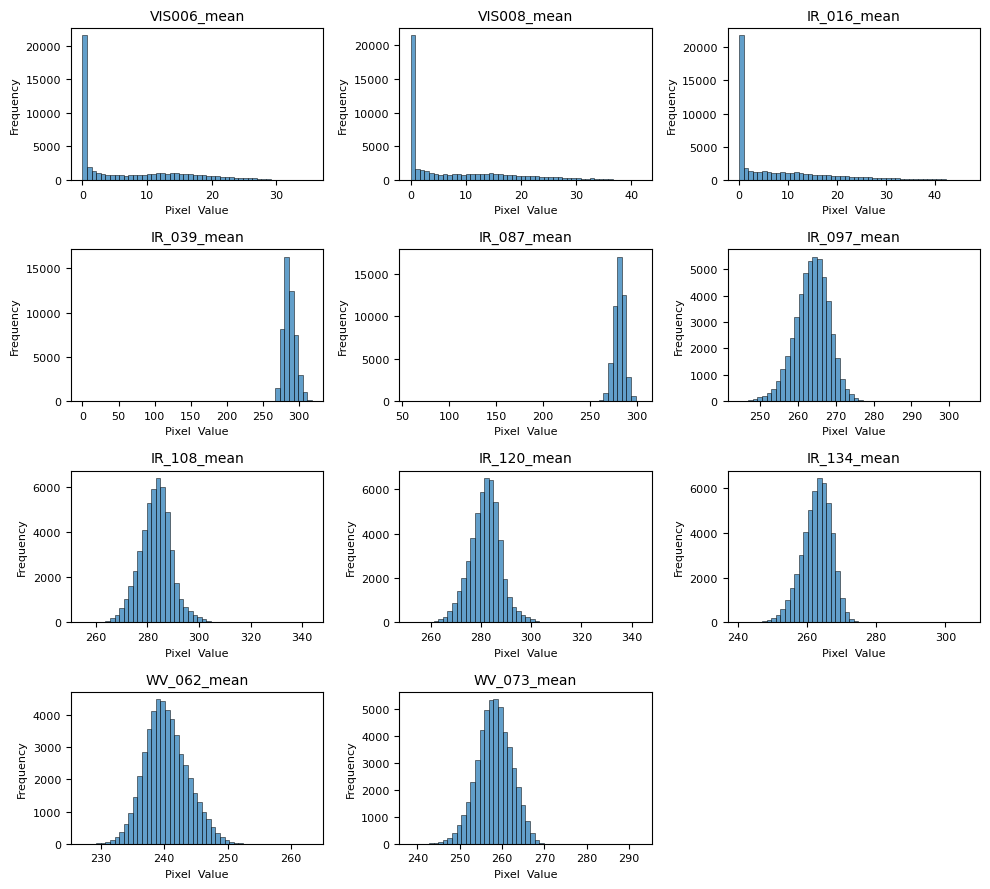

In [58]:
# Alternative: More control over individual subplots
n_rows = 4
n_cols = 3
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 9))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    if i < len(axes):
        axes[i].hist(data[col].dropna(), bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel('Pixel  Value', fontsize=8)
        axes[i].set_ylabel('Frequency', fontsize=8)
        axes[i].grid(False)  # Remove grid for each subplot
        axes[i].tick_params(axis='both', which='major', labelsize=8)

# Hide any unused subplots
for i in range(len(data.columns), len(axes)):
    axes[i].set_visible(False)

# plt.suptitle(f'{satellite} Channel {metric.capitalize()} Value Distributions', fontsize=16)
plt.tight_layout()
plt.savefig(f'{satellite}_{metric}_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [211]:
# Visualize Images

msg_path = '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/msg/l1b'
msg_files = [os.path.join(msg_path, f) for f in os.listdir(msg_path) if f.endswith('.nc')]

goes_path = '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip'
goes_files = [os.path.join(goes_path, f) for f in os.listdir(goes_path) if f.endswith('.nc')]

him_path = '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/himawari/l1b'
him_files = [os.path.join(him_path, f) for f in os.listdir(him_path) if f.endswith('.nc')]

paths = {
    'MSG': msg_path,
    'GOES': goes_path,
    'Himawari': him_path
}

In [150]:
example_file = him_files[np.random.randint(len(him_files))]
example_file

'/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/himawari/l1b/20151210074000_patch_1147_819.nc'

In [151]:
ds = xr.open_dataset(example_file)

getfattr: /data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/himawari/l1b/20151210074000_patch_1147_819.nc: Operation not supported


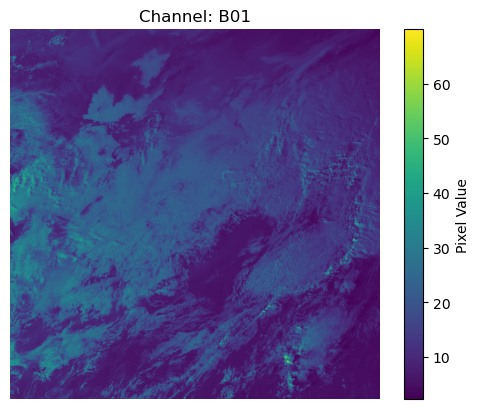

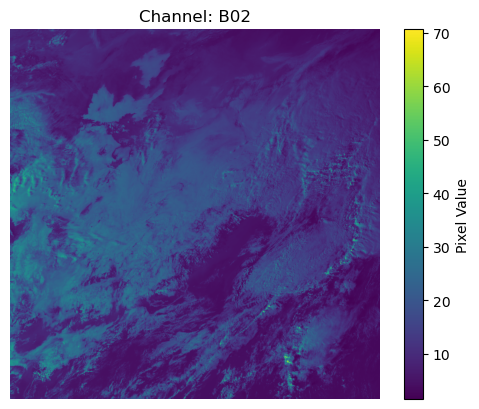

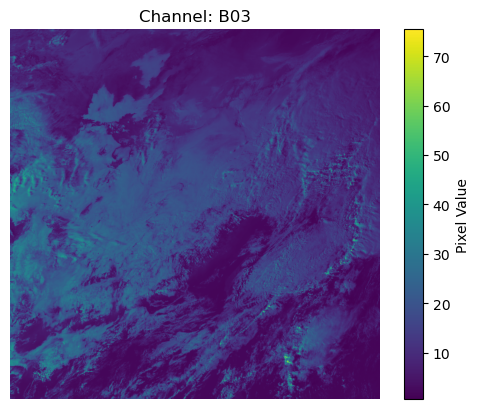

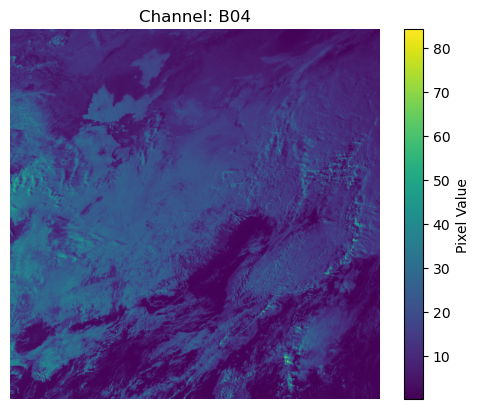

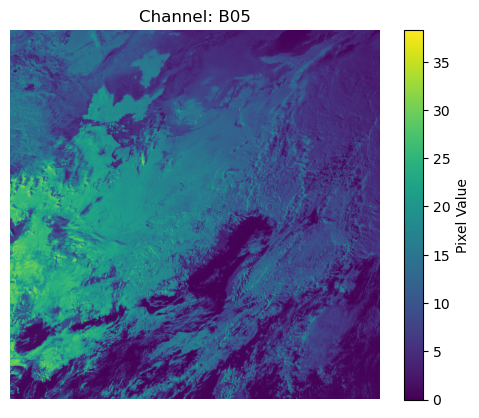

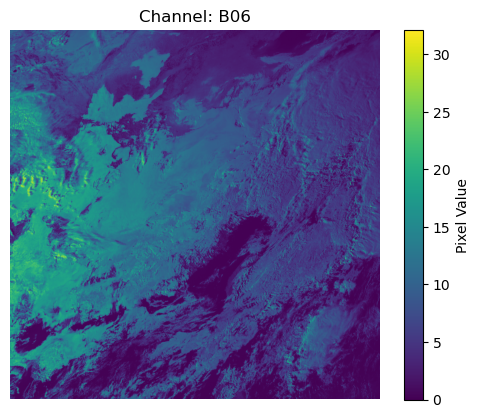

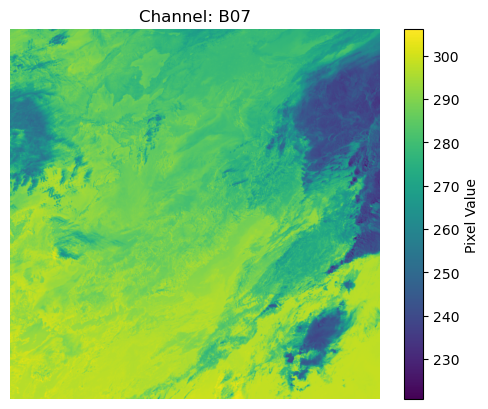

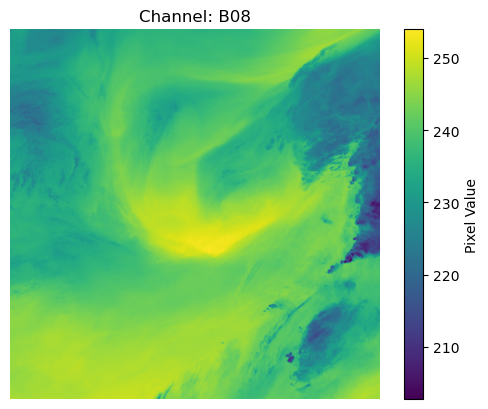

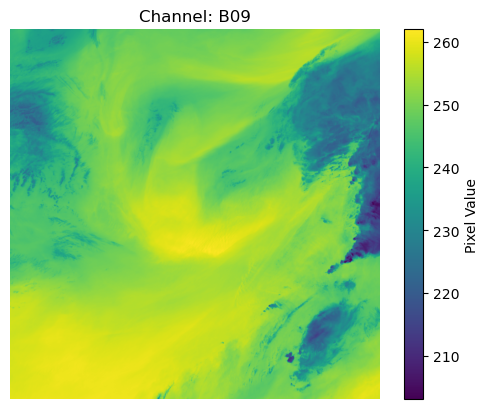

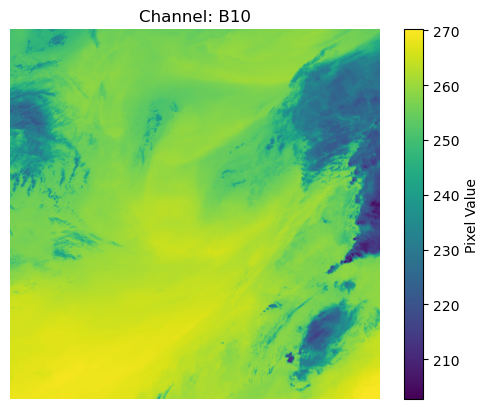

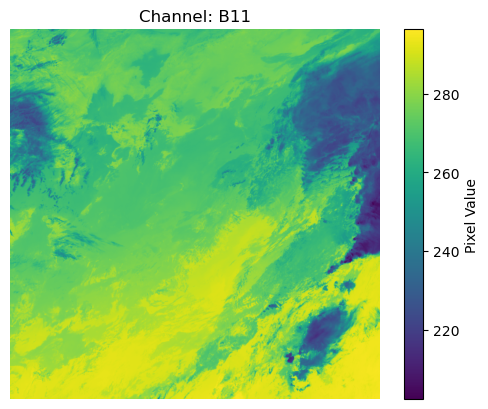

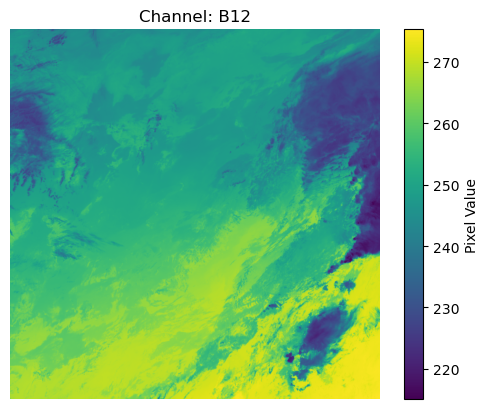

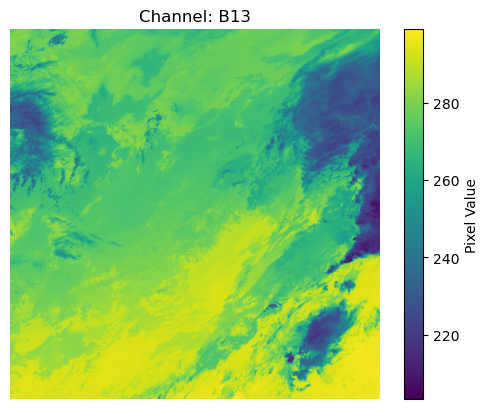

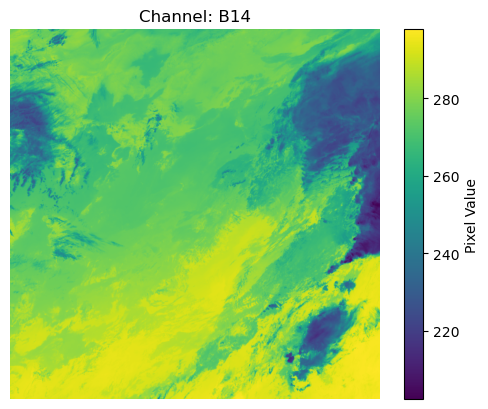

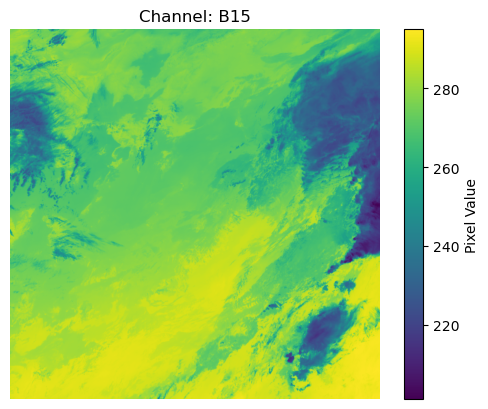

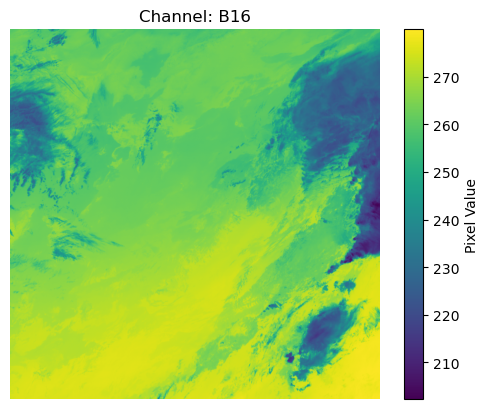

In [153]:
for channel in range(ds.data.shape[0]):
    img = ds.data[channel].values
    plt.figure()
    plt.imshow(img)
    plt.title(f'Channel: {ds.channel.values[channel]}')
    plt.colorbar(label='Pixel Value')
    plt.axis('off')
    plt.savefig(f'example_{ds.channel.values[channel]}.png', dpi=300, bbox_inches='tight')

# Investigating night time observations

In [8]:
df

,file,sensor,time,lat,lon,sat_zenith,sat_azimuth,solar_zenith,solar_azimuth,bad_pixels,...,B14_mean,B14_std,B15_min,B15_max,B15_mean,B15_std,B16_min,B16_max,B16_mean,B16_std
0,20180102210039_patch_907_983.nc,GOES,2018-01-02 21:05:57.567625024,23.754288,-103.145220,42.376415,313.37158,56.832867,143.697310,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20180102221539_patch_1638_2684.nc,GOES,2018-01-02 22:20:57.879809984,-8.925537,-85.497740,17.378174,229.53441,67.185490,111.128685,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20180102221539_patch_3248_3501.nc,GOES,2018-01-02 22:20:57.879809984,-25.384842,-52.344240,39.436913,141.28351,90.167780,115.830390,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20180103011539_patch_2758_3172.nc,GOES,2018-01-03 01:20:57.631253952,-18.310730,-64.033510,25.716702,150.43558,119.668724,131.444930,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20180103011539_patch_2834_1994.nc,GOES,2018-01-03 01:20:57.631253952,3.781342,-63.278350,15.921446,72.87954,133.103590,118.113396,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,20250228071242_patch_1064_1236.nc,MSG,2025-02-28 07:12:42,-2.978348,7.803146,15.172997,110.49594,67.341470,97.268814,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149996,20250228071242_patch_673_1371.nc,MSG,2025-02-28 07:12:42,0.769165,19.205902,24.640146,87.77690,56.784023,100.034454,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149997,20250228141242_patch_1437_2376.nc,MSG,2025-02-28 14:12:42,31.082428,-3.215668,37.860485,354.94955,47.677967,141.904240,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149998,20250228181243_patch_895_587.nc,MSG,2025-02-28 18:12:43,-21.929535,13.986527,31.729897,149.94620,99.479380,102.893870,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [216]:
satellite = 'Himawari'
vars = ['min', 'max', 'mean', 'std']

columns = ['file', 'sensor', 'time', 'lat', 'lon', 'sat_zenith', 'sat_azimuth',
       'solar_zenith', 'solar_azimuth', 'bad_pixels']
columns.extend([f'{channels[satellite][0]}_{var}' for var in vars])
data = df[columns]
data = data[data['sensor'] == satellite]
data = data.reset_index(drop=True)

In [218]:
len(data)

50000

In [220]:
# Convert string time column to datetime objects
data['time'] = pd.to_datetime(data['time'], format='mixed')

In [221]:
type(data['time'][0])

pandas._libs.tslibs.timestamps.Timestamp

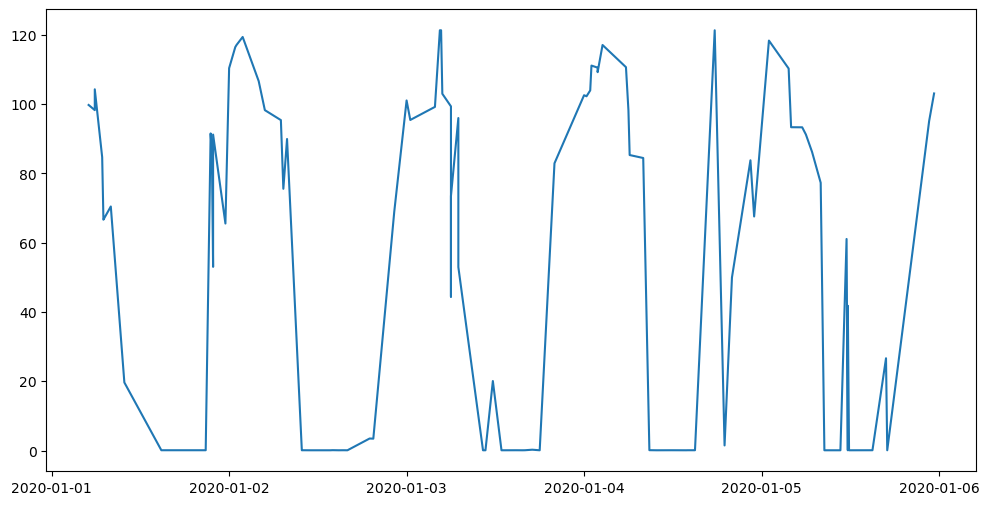

In [223]:
metric = 'max'
time_start = pd.to_datetime('2020-01-01 00:00:00')
time_end = pd.to_datetime('2020-01-05 23:59:59')
data_subset = data[(data['time'] >= time_start) & (data['time'] <= time_end)]

plt.figure(figsize=(12, 6))
plt.plot(data_subset['time'], data_subset[f'{channels[satellite][0]}_{metric}'])

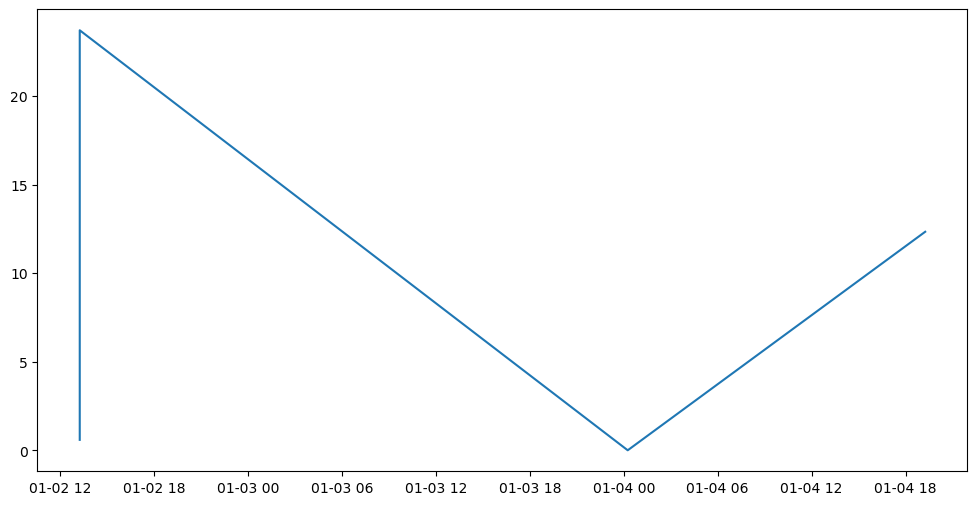

In [187]:
metric = 'mean'
time_start = pd.to_datetime('2020-01-01 00:00:00')
time_end = pd.to_datetime('2020-01-05 23:59:59')
data_subset = data[(data['time'] >= time_start) & (data['time'] <= time_end)]

plt.figure(figsize=(12, 6))
plt.plot(data_subset['time'], data_subset[f'{channels[satellite][0]}_{metric}'])

In [224]:
min(data_subset[f'{channels[satellite][0]}_max']), max(data_subset[f'{channels[satellite][0]}_max'])

(0.0915555283427238, 121.25614166259766)

Text(0.5, 0, 'Himawari B01 mean')

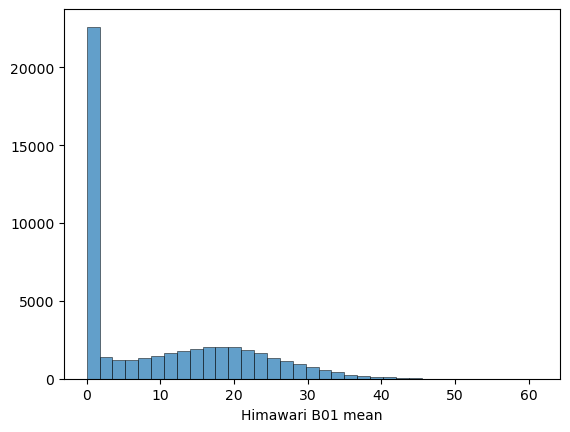

In [225]:
plt.hist(data[f'{channels[satellite][0]}_mean'].dropna(), bins=35, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.xlabel(f'{satellite} {channels[satellite][0]} mean')

In [247]:
low = 5

data_subset = data[data[f'{channels[satellite][0]}_mean'] >= low]

In [248]:
len(data_subset)

24952

In [241]:
random_file = np.random.choice(data_subset['file'].values)

In [242]:
test_file = xr.open_dataset(f'{paths[satellite]}/{random_file}')

getfattr: /data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/himawari/l1b/20180423020000_patch_2712_1290.nc: Operation not supported


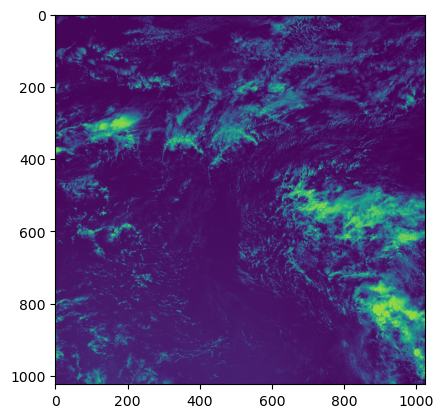

In [246]:
plt.imshow(test_file.data.values[3])

In [249]:
import glob
def get_list_filenames(data_path: str = "./", ext: str = "*"):
    """
    Loads a list of file names within a directory.

    Args:
        data_path (str, optional): The directory path to search for files. Defaults to "./".
        ext (str, optional): The file extension to filter the search. Defaults to "*".

    Returns:
        List[str]: A sorted list of file names matching the given extension within the directory.
    """
    pattern = f"*{ext}"
    return sorted(glob.glob(os.path.join(data_path, "**", pattern), recursive=True))

In [ ]:
def filter_files_by_metric(files, stats_df, satellite, metric_column, threshold):
    """Filter files based on a metric threshold for a specific satellite."""
    
    # Filter stats in one operation
    stats_subset = (stats_df
                   .query(f'sensor == "{satellite}" and {metric_column} >= {threshold}')
                   .reset_index(drop=True))
    
    print(f"Found {len(stats_subset)} files meeting threshold")
    
    # Convert to set for O(1) lookup instead of O(n) for each file
    valid_files = set(stats_subset['file'].values)
    
    # Use list comprehension with set lookup (much faster than checking pandas Series)
    filtered_files = [file for file in files 
                     if os.path.basename(file) in valid_files]
    
    return filtered_files

In [275]:
satellite = 'GOES'

In [276]:
files = get_list_filenames(data_path=paths[satellite], ext='.nc')

In [278]:
filtered_files = filter_files_by_metric(files, df, satellite, f'{channels[satellite][0]}_mean', 5)

Found 19083 files meeting threshold


In [279]:
filtered_files

['/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180102210039_patch_907_983.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180102221539_patch_1638_2684.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180103120039_patch_1407_3579.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180103131539_patch_3028_548.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180103194539_patch_484_2684.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180104103039_patch_3866_1277.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180104133039_patch_1739_1073.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mcmip/20180104134539_patch_1320_2989.nc',
 '/data/2025-esl-3dclouds-extremes-datasets/pre-training-reprocessed/goes/mc